## Trabajo en clase 04: Integración numerica

**Nombre completo:Efraín Rojas García**

**Carné:C36883**

### Fecha de entrega
Lunes 20 de setiembre de 2026, 23:59 h.

### Instrucciones generales
Lea los enunciados de los siguientes dos ejercicios, **complete el código** faltante y **responda a las preguntas planteadas**.

### Formato de entrega
Guarde el notebook en una carpeta llamanda `04-Trabajo_en_clase` y subir a su repositorio privado en GitHub.


## Integración numérica: trapecio compuesto y Simpson compuesto

El objetivo de este ejercicio es aproximar una integral definida utilizando dos métodos de cuadratura numérica y estudiar cómo cambia el error al refinar la malla.

Considere la integral

$$
I = \int_0^1 \frac{4}{1+x^2}\,dx.
$$

Esta integral puede calcularse analíticamente:

$$
I = 4\left[\arctan(x)\right]_0^1 = \pi.
$$

Por lo tanto, utilizaremos

$$
I_{\mathrm{exacta}}=\pi
$$

para determinar el error de las aproximaciones numéricas.

Se estudiarán los métodos de:

- trapecio compuesto,
- Simpson compuesto.

Utilizaremos los números de subintervalos

$$
n\in\{4,8,16,32,64\}.
$$

### 1. Implementación de la función a integrar (10 puntos)

Defina una función en Python:

- `func(x)`: devuelve el valor de

$$
f(x)=\frac{4}{1+x^2}.
$$

La función debe poder recibir tanto un único valor de $x$ como un arreglo de NumPy.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def func(x):
    '''
    TODO:
    Complete aquí la definición de la función

                 4
        f(x) = -------
                1+x^2
    '''
    f= 4/(1+x**2)
    
    return f

### 2. Regla del trapecio compuesto (20 puntos)

Divida el intervalo $[a,b]$ en $n$ subintervalos de igual ancho

$$
h=\frac{b-a}{n}.
$$

La regla del trapecio compuesto aproxima la integral mediante

$$
I_T =
h\left[
\frac{f(x_0)+f(x_n)}{2}
+
\sum_{i=1}^{n-1}f(x_i)
\right].
$$

Implemente la función:

- `trapecio_compuesto(f, a, b, n)`

donde:

- `f` es la función que se desea integrar,
- `a` y `b` son los límites de integración,
- `n` es el número de subintervalos.

La función debe construir los $n+1$ nodos necesarios y devolver la aproximación numérica de la integral.

In [10]:
def trapecio_compuesto(f, a, b, n):
    '''
    TODO:
    Implemente aquí la regla del trapecio compuesto.

    Sugerencia:
    1. Calcule el ancho h de cada subintervalo.
    2. Construya los n+1 nodos.
    3. Evalúe f(x) en los nodos.
    4. Aplique la expresión del trapecio compuesto.
    '''
    h=(b-a)/n
    x_nodos=np.linspace(a,b, n+1)
    y= f(x_nodos)
    
    ITC= h*((y[0] + y[-1])/2 + (np.sum(y[1:-1:1])))
            # de 0 a el ultimo que es expresado como -1
            # ya que el final es exclusivo         
    return ITC

### 3. Regla de Simpson compuesta (20 puntos)

Para un número **par** de subintervalos $n$, la regla de Simpson compuesta está dada por

$$
I_S =
\frac{h}{3}
\left[
f(x_0)+f(x_n)
+
4\sum_{\substack{i=1\\i\text{ impar}}}^{n-1}f(x_i)
+
2\sum_{\substack{i=2\\i\text{ par}}}^{n-2}f(x_i)
\right],
$$

donde

$$
h=\frac{b-a}{n}.
$$

Implemente la función:

- `simpson_compuesto(f, a, b, n)`

La implementación debe utilizar los pesos correspondientes:

$$
1,\;4,\;2,\;4,\;2,\ldots,\;4,\;1.
$$

**Importante:** la regla de Simpson compuesta requiere que $n$ sea par. Los valores de $n$ utilizados en este ejercicio cumplen esta condición.

In [11]:
def simpson_compuesto(f, a, b, n):
    '''
    TODO:
    Implemente aquí la regla de Simpson compuesta.

    Sugerencia:
    1. Calcule h.
    2. Construya los n+1 nodos.
    3. Evalúe f(x) en los nodos.
    4. Sume por separado los términos con índices
       impares y pares.
    5. Aplique la expresión de Simpson compuesto.
    '''
    if n%2 !=0:
        raise ValueError
        
    h= (b-a)/n
    x_nodos= np.linspace(a,b, n+1)
    y=f(x_nodos)
                  
    sum_impar=np.sum(y[1:-1:2])
    sum_par= np.sum(y[2:-2:2])
                    #inicio:final:salto 2 en 2
    ISC= h/3 * (y[0]+ y[-1] + 4*sum_impar + 2*sum_par)
                    
    return ISC

### 4. Aproximaciones y error real (15 puntos)

Utilice

$$
n\in\{4,8,16,32,64\}
$$

para aproximar la integral con ambos métodos.

Para cada valor de $n$:

1. Calcule la aproximación mediante trapecio compuesto.
2. Calcule la aproximación mediante Simpson compuesto.
3. Compare ambas aproximaciones con

$$
I_{\mathrm{exacta}}=\pi.
$$

El **error absoluto real** de una aproximación numérica se define como

$$
E_{\mathrm{real}}
=
|I_{\mathrm{num}}-I_{\mathrm{exacta}}|.
$$

Calcule el error real para ambos métodos.

Almacene los resultados en las listas proporcionadas para utilizarlos posteriormente.

In [15]:
# Configuración del experimento
a = 0
b = 1

I_exacta = np.pi

valores_n = [4, 8, 16, 32, 64]

# Listas para almacenar resultados
aprox_trapecio = []
aprox_simpson = []

error_trapecio = []
error_simpson = []

for n in valores_n:

    '''
    TODO:
    Calcule las aproximaciones utilizando
    trapecio compuesto y Simpson compuesto.
    '''

    I_T = trapecio_compuesto(func, a, b, n)
    I_S = simpson_compuesto(func, a, b, n)

    '''
    TODO:
    Calcule los errores absolutos reales.
    '''

    E_T = np.abs(I_exacta - I_T)
    E_S = np.abs(I_exacta - I_S)

    # Almacenar resultados
    aprox_trapecio.append(I_T)
    aprox_simpson.append(I_S)

    error_trapecio.append(E_T)
    error_simpson.append(E_S)

### 5. Estimación del error mediante refinamiento de malla (15 puntos)

En aplicaciones reales, generalmente no conocemos el valor exacto de la integral. Por esta razón, es útil estimar el error comparando aproximaciones calculadas con diferentes tamaños de paso.

Considere dos aproximaciones sucesivas:

- $I$: calculada utilizando $n$ subintervalos,
- $I_{2}$: calculada utilizando $2n$ subintervalos.

Para un método cuyo error es de orden $O(h^p)$, el error de la aproximación más refinada puede estimarse mediante

$$
\epsilon_2
\approx
\frac{1}{2^p-1}
\left|I_{2}-I\right|.
$$

#### Regla del trapecio

La regla del trapecio compuesto tiene error de orden

$$
O(h^2),
$$

por lo que

$$
\epsilon_2^{(T)}
\approx
\frac{1}{3}
\left|I_{2}^{(T)}-I^{(T)}\right|.
$$

#### Regla de Simpson

La regla de Simpson compuesta tiene error de orden

$$
O(h^4),
$$

por lo que

$$
\epsilon_2^{(S)}
\approx
\frac{1}{15}
\left|I_{2}^{(S)}-I^{(S)}\right|.
$$

Calcule ambas estimaciones para los pares

$$
(4,8),\quad(8,16),\quad(16,32),\quad(32,64).
$$

Compare posteriormente cada estimación con el error real de la aproximación más refinada.

In [17]:
# Listas para almacenar los errores estimados
eps2_trapecio = [np.nan]
eps2_simpson = [np.nan]

for i in range(1, len(valores_n)):

    '''
    TODO:
    Calcule la diferencia entre las aproximaciones
    consecutivas del método del trapecio.
    '''

    diff_t = np.abs(aprox_trapecio[i]-aprox_trapecio[i-1])
    diff_s = np.abs(aprox_simpson[i]-aprox_simpson[i-1])

    '''
    TODO:
    Utilice la diferencia para calcular

        eps2 = (1/3) |I_2n - I_n|
        eps2 = (1/15) |I_2n - I_n|
    '''

    eps2_t = (1/3)*diff_t
    eps2_s = (1/15)*diff_s

    eps2_trapecio.append(eps2_t)
    eps2_simpson.append(eps2_s)

### 6. Organización y visualización de resultados (10 puntos)

Organice los resultados obtenidos en una tabla que contenga:

- número de subintervalos $n$,
- aproximación mediante trapecio,
- error real del trapecio,
- error estimado $\epsilon_2$,
- aproximación mediante Simpson,
- error real de Simpson.

Posteriormente, grafique los errores reales de ambos métodos en función de $n$.

Utilice una escala logarítmica en ambos ejes para facilitar la comparación de la disminución del error.

In [18]:
tabla = pd.DataFrame({
    'n': valores_n,
    'Aprox. Trapecio': aprox_trapecio,
    'Error Real T': error_trapecio,
    'eps2 Trapecio': eps2_trapecio,
    'Aprox. Simpson': aprox_simpson,
    'Error Real S': error_simpson,
    'eps2 Simpson': eps2_simpson
})

pd.options.display.float_format = '{:.6e}'.format

tabla

,n,Aprox. Trapecio,Error Real T,eps2 Trapecio,Aprox. Simpson,Error Real S,eps2 Simpson
0,4,3.131176e+00,1.041618e-02,NaN,3.141569e+00,2.402614e-05,NaN
1,8,3.138988e+00,2.604159e-03,2.604008e-03,3.141593e+00,1.511311e-07,1.591667e-06
2,16,3.140942e+00,6.510415e-04,6.510392e-04,3.141593e+00,2.364971e-09,9.917741e-09
3,32,3.141430e+00,1.627604e-04,1.627604e-04,3.141593e+00,3.695666e-11,1.552010e-10
4,64,3.141552e+00,4.069010e-05,4.069010e-05,3.141593e+00,5.773160e-13,2.425290e-12


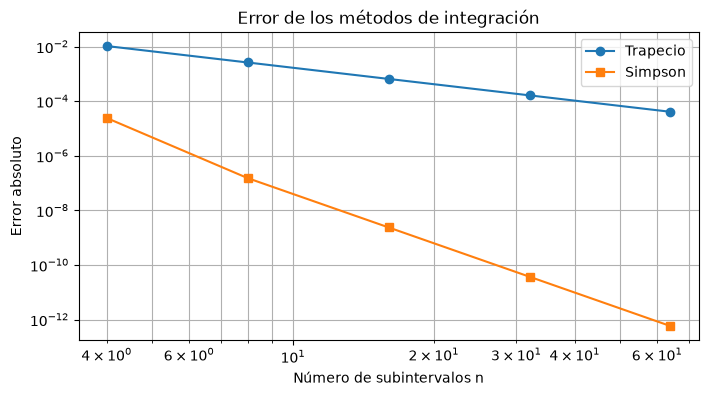

In [19]:
# Comparación gráfica de los errores reales

plt.figure(figsize=(8, 4))

plt.loglog(valores_n, error_trapecio, 'o-', label='Trapecio')
plt.loglog(valores_n, error_simpson, 's-', label='Simpson')

plt.xlabel('Número de subintervalos n')
plt.ylabel('Error absoluto')
plt.title('Error de los métodos de integración')
plt.legend()
plt.grid(True, which='both')
plt.show()

### 7. Discusión (10 puntos)

Responda brevemente utilizando los resultados de la tabla y la gráfica:

1. ¿Cómo cambia el error de la regla del trapecio al aumentar el número de subintervalos $n$?

2. ¿Cómo cambia el error de la regla de Simpson al aumentar $n$?

3. Para un mismo número de subintervalos, ¿cuál de los dos métodos produce una aproximación más precisa para esta integral?

4.  Compare las estimaciones $\epsilon_2$ y $\epsilon_4$ con los errores reales
correspondientes. ¿Cuál de las dos estimaciones reproduce mejor el error real?

5. La regla del trapecio compuesto tiene un error de orden

$$
O(h^2),
$$

mientras que la regla de Simpson compuesta tiene un error de orden

$$
O(h^4).
$$

Como al duplicar $n$ el tamaño de paso $h$ se reduce aproximadamente a la mitad, ¿qué reducción del error esperaría teóricamente para cada método? Compare esta predicción con sus resultados numéricos.

## Resultados

1. El error de trapecio compuesto, decrese el error al aumentar los N

2. En el error de simpson compuesto decrese al aumentar el N

3. El metodo de Simpson compuesto presenta una aproximacion mas precisa, visto calramente en ma grafica de error, solo ver la diferencia $n=6x10$ entre trapecio y simpson.

4. El $\epsilon_2$ de la regla del trapecio y el error real son practicamente iguales, mientras se aumenta el n, mejora la concordancia del error.
En el emtodo de simpson sucede igual, pero no con la misma precisión, entonces concluimos que para la regla del trapecio tiene mejor aproximacion al error real, pero el de simpson son de ordenes de magnitud mas pequeños.

5. Por obvias razones, el error de trapecio disminuiria por un factor de 4, ya que es elevado a la 2, y con simpson seria por 16. 
Pero los resultados muestran una dismunucion mayor

$$
\frac{1.511311\times10^{-7}}
     {2.364971\times10^{-9}}
\approx 63.9,
$$

se obtiene aproximadamente un factor casi de 64, el trapecio presenta exactamente el comportamiento esperado de orden \(h^2\), pero Simpson converge incluso más rápido que la predicción general de \(h^4\) para esta función particular.